In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import streamlit as st
from pathlib import Path

In [5]:
candidates = [
    Path('sprint_5/notebook/vehicles.csv'),
    Path('notebook/vehicles.csv'),
    Path('vehicles.csv'),
]

data_path = next((path for path in candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError('Could not find vehicles.csv in the expected locations.')

data = pd.read_csv(data_path)

print(data.describe())

               price    model_year     cylinders       odometer   is_4wd  \
count   51525.000000  47906.000000  46265.000000   43633.000000  25572.0   
mean    12132.464920   2009.750470      6.125235  115553.461738      1.0   
std     10040.803015      6.282065      1.660360   65094.611341      0.0   
min         1.000000   1908.000000      3.000000       0.000000      1.0   
25%      5000.000000   2006.000000      4.000000   70000.000000      1.0   
50%      9000.000000   2011.000000      6.000000  113000.000000      1.0   
75%     16839.000000   2014.000000      8.000000  155000.000000      1.0   
max    375000.000000   2019.000000     12.000000  990000.000000      1.0   

       days_listed  
count  51525.00000  
mean      39.55476  
std       28.20427  
min        0.00000  
25%       19.00000  
50%       33.00000  
75%       53.00000  
max      271.00000  


In [6]:
# Preencher valores ausentes em colunas numéricas com a mediana para evitar distorções por outliers
# As colunas 'model_year', 'cylinders' e 'odometer' parecem numéricas e possuem NaNs.
for col in ['model_year', 'cylinders', 'odometer']:
    if col in data.columns:
        if data[col].isnull().any():
            median_val = data[col].median()
            data[col] = data[col].fillna(median_val)
            print(f"Valores ausentes da coluna '{col}' preenchidos com a mediana: {median_val}")

# Preencher valores ausentes em 'paint_color' e 'is_4wd' com 'unknown' ou 0, respectivamente
# 'paint_color' é categórica, 'is_4wd' é binária e pode ser tratada como 0/1
if 'paint_color' in data.columns:
    if data['paint_color'].isnull().any():
        data['paint_color'] = data['paint_color'].fillna('unknown')
        print("Valores ausentes da coluna 'paint_color' preenchidos com 'unknown'")

if 'is_4wd' in data.columns:
    if data['is_4wd'].isnull().any():
        # Assumindo que NaN em 'is_4wd' significa que não é 4WD (0)
        data['is_4wd'] = data['is_4wd'].fillna(0.0) # Usar 0.0 para manter o tipo float se necessário
        print("Valores ausentes da coluna 'is_4wd' preenchidos com 0.0")

# Exibir novamente informações sobre o DataFrame para confirmar o tratamento de NaNs
print("\nInformações do DataFrame após tratamento de valores ausentes:")
data.info()

Valores ausentes da coluna 'model_year' preenchidos com a mediana: 2011.0
Valores ausentes da coluna 'cylinders' preenchidos com a mediana: 6.0
Valores ausentes da coluna 'odometer' preenchidos com a mediana: 113000.0
Valores ausentes da coluna 'paint_color' preenchidos com 'unknown'
Valores ausentes da coluna 'is_4wd' preenchidos com 0.0

Informações do DataFrame após tratamento de valores ausentes:
<class 'pandas.DataFrame'>
RangeIndex: 51525 entries, 0 to 51524
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         51525 non-null  int64  
 1   model_year    51525 non-null  float64
 2   model         51525 non-null  str    
 3   condition     51525 non-null  str    
 4   cylinders     51525 non-null  float64
 5   fuel          51525 non-null  str    
 6   odometer      51525 non-null  float64
 7   transmission  51525 non-null  str    
 8   type          51525 non-null  str    
 9   paint_color   51525 

2026-07-13 19:43:07.328 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:43:08.484 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:43:09.715 
  command:

    streamlit run c:\Users\Taujiro\anaconda3\envs\sprint_5\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-13 19:43:09.716 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:43:09.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

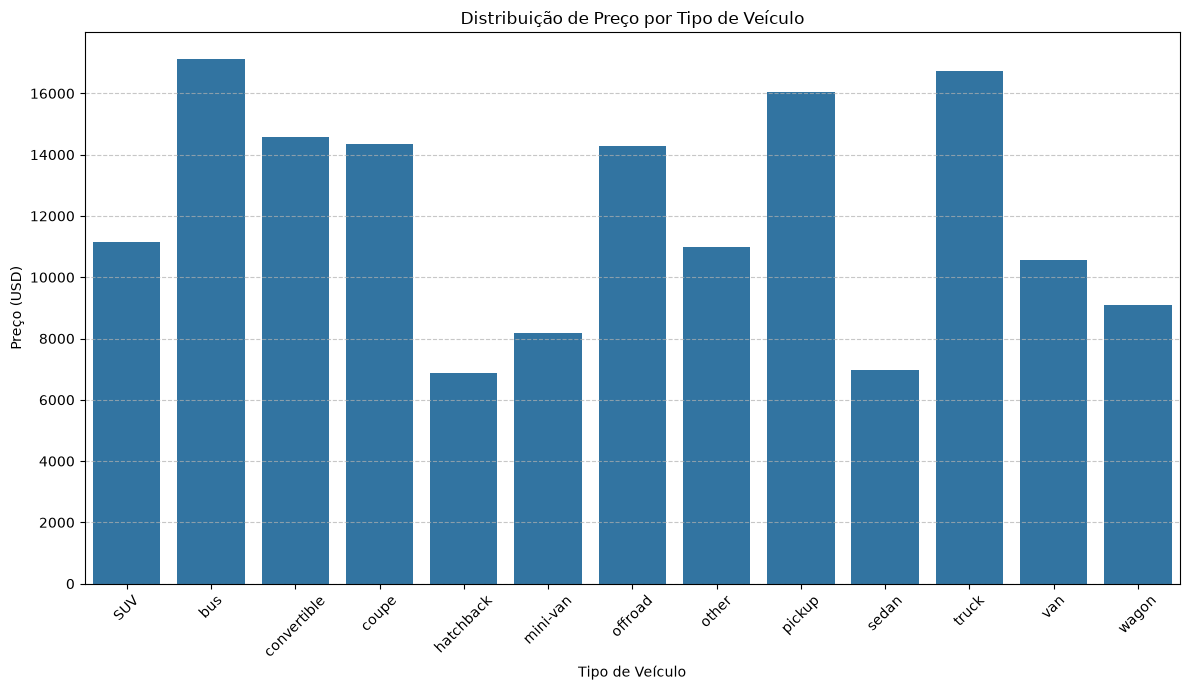

In [7]:
mean_price_by_type = data.groupby('type')['price'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='type', y='price', data=mean_price_by_type)
plt.title('Distribuição de Preço por Tipo de Veículo')
plt.xlabel('Tipo de Veículo')
plt.ylabel('Preço (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
st.pyplot(plt.gcf())

### Análise 2: Relação entre Odômetro e Preço

Vamos investigar a correlação entre a quilometragem (odômetro) de um veículo e seu preço. Esperamos ver uma tendência de preços mais baixos para veículos com maior quilometragem. Um gráfico de dispersão pode nos ajudar a visualizar essa relação.

In [11]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='odometer', y='price', data=data, alpha=0.6)
plt.title('Relação entre Odômetro e Preço do Veículo')
plt.xlabel('Odômetro (Milhas)')
plt.ylabel('Preço (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
st.pyplot(plt.gcf())

2026-07-13 19:44:22.989 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:44:24.792 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:44:24.793 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:44:24.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### Análise 3: Contagem de Veículos por Condição

Vamos visualizar a distribuição das condições dos veículos. Isso nos dará uma ideia de quantos veículos estão em cada categoria de condição (ex: 'good', 'excellent', 'like new', etc.) no dataset.

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(y='condition', data=data, order=data['condition'].value_counts().index)
plt.title('Contagem de Veículos por Condição')
plt.xlabel('Número de Veículos')
plt.ylabel('Condição')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
st.pyplot(plt.gcf())

2026-07-13 19:45:47.623 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:45:48.485 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:45:48.486 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 19:45:48.488 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### Análise 4: Distribuição Geral dos Preços dos Veículos

Vamos criar um histograma para visualizar a distribuição dos preços de todos os veículos no dataset. Isso nos ajudará a entender as faixas de preço mais comuns e a forma geral da distribuição dos preços.

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Distribuição Geral dos Preços dos Veículos')
plt.xlabel('Preço (USD)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
st.pyplot(plt.gcf())